In [5]:
# -*- coding: utf-8 -*-
"""
연구과제: 안정동위원소 결합 오염평가 체계 고도화를 위한 국가 수질측정망 적용 연구
파일명: pollution_source_integrated_framework_v3_fixed.py
목적: 
  1) 11대 전 범주 완벽 지원 수질-동위원소 End-member 기반 가상 데이터 증강
  2) 하이브리드 의사 라벨링 룰셋 및 LLM 프롬프트 고도화
  3) 계층적 분류 및 미학습 오염원(OOD) 자동 탐지
  4) Focal Loss 및 Class Weight 적용 22대 ML/DL 앙상블 재학습
  5) 평가 데이터(test_ver3.csv) 6대 파생변수 산출 및 통합 예측
"""

import os
import time
import json
import warnings
import numpy as np
import pandas as pd
from scipy.stats import norm, linregress

# Scikit-Learn 전처리, 모델 및 결측치 대치
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier

# 외부 머신러닝 라이브러리
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# PyTorch 딥러닝 모듈
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# 시드 고정 (재현성 확보)
def seed_everything(seed=3606):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything()

In [6]:
# ==========================================
# 0. API 및 환경 설정 & End-Member 학술 프로필 정의
# ==========================================
try:
    import google.generativeai as genai
    genai.configure(api_key=os.environ.get("GEMINI_API_KEY", "YOUR_API_KEY_HERE"))
    HAS_GENAI = True
except ImportError:
    HAS_GENAI = False
    print("[!] 'google-generativeai' 패키지가 없습니다. LLM 구간은 백업 추론 모드로 작동합니다.")

# 11대 오염원 판별 범주 (소분류)
POLLUTION_CATEGORIES = [
    "대기유입/초기강우",
    "탈질작용(기원변형)",
    "산업/인위적 점오염",
    "축산분뇨(직접유출)",
    "생활하수/처리수 영향",
    "조류증식(현장발생)",
    "내생부하(정체수역 유기물 축적)",
    "화학비료(농경지)",
    "유기질비료(퇴비) 영향",
    "토양-질소 기원",
    "자연배경/특이징후 없음"
]

# 계층적 대분류 매핑 딕셔너리
HIERARCHICAL_MAP = {
    "산업/인위적 점오염": "점오염원",
    "축산분뇨(직접유출)": "점오염원",
    "생활하수/처리수 영향": "점오염원",
    "대기유입/초기강우": "비점오염원",
    "화학비료(농경지)": "비점오염원",
    "유기질비료(퇴비) 영향": "비점오염원",
    "토양-질소 기원": "비점오염원",
    "탈질작용(기원변형)": "자연/내생/기원변형",
    "조류증식(현장발생)": "자연/내생/기원변형",
    "내생부하(정체수역 유기물 축적)": "자연/내생/기원변형",
    "자연배경/특이징후 없음": "자연/내생/기원변형"
}

# 11대 오염원별 도메인 학술 End-Member 기준 분포 (평균, 표준편차)
# 데이터 0건 발생 시 가상 표본 생성을 위한 과학적 하한/상한 프로필
ENDMEMBER_PROFILES = {
    "대기유입/초기강우": {
        'pH': (6.2, 0.4), 'DO': (9.5, 0.8), 'BOD': (1.2, 0.4), 'EC': (120, 30),
        'TOC': (2.5, 0.8), 'TN': (1.5, 0.5), 'TP': (0.04, 0.02), 'Cl': (8.0, 3.0),
        'NO3N': (0.8, 0.3), 'NH3N': (0.2, 0.1), 'd15N': (-1.5, 1.5), 'd18O': (28.0, 6.0)
    },
    "탈질작용(기원변형)": {
        'pH': (7.4, 0.3), 'DO': (5.0, 1.2), 'BOD': (2.8, 0.8), 'EC': (320, 60),
        'TOC': (4.0, 1.0), 'TN': (4.5, 1.2), 'TP': (0.12, 0.04), 'Cl': (25.0, 8.0),
        'NO3N': (2.5, 0.8), 'NH3N': (0.3, 0.1), 'd15N': (15.5, 3.0), 'd18O': (11.5, 2.5)
    },
    "산업/인위적 점오염": {
        'pH': (7.1, 0.5), 'DO': (6.2, 1.0), 'BOD': (6.5, 2.0), 'EC': (650, 120),
        'TOC': (8.5, 2.5), 'TN': (7.0, 2.0), 'TP': (0.45, 0.15), 'Cl': (85.0, 25.0),
        'NO3N': (4.0, 1.5), 'NH3N': (1.2, 0.5), 'd15N': (6.5, 2.0), 'd18O': (4.5, 1.5)
    },
    "축산분뇨(직접유출)": {
        'pH': (7.6, 0.4), 'DO': (4.5, 1.5), 'BOD': (12.0, 4.0), 'EC': (850, 180),
        'TOC': (16.0, 5.0), 'TN': (14.0, 4.0), 'TP': (1.20, 0.40), 'Cl': (110.0, 30.0),
        'NO3N': (6.5, 2.5), 'NH3N': (4.5, 1.8), 'd15N': (17.5, 3.5), 'd18O': (7.5, 2.0)
    },
    "생활하수/처리수 영향": {
        'pH': (7.3, 0.3), 'DO': (6.8, 0.9), 'BOD': (4.5, 1.2), 'EC': (480, 90),
        'TOC': (6.0, 1.5), 'TN': (5.5, 1.5), 'TP': (0.25, 0.08), 'Cl': (45.0, 12.0),
        'NO3N': (3.5, 1.0), 'NH3N': (0.8, 0.3), 'd15N': (9.5, 1.8), 'd18O': (3.8, 1.2)
    },
    "조류증식(현장발생)": {
        'pH': (8.8, 0.4), 'DO': (11.0, 1.5), 'BOD': (7.5, 2.0), 'EC': (280, 50),
        'TOC': (14.5, 3.0), 'TN': (2.2, 0.6), 'TP': (0.15, 0.05), 'Cl': (20.0, 5.0),
        'NO3N': (0.6, 0.3), 'NH3N': (0.15, 0.08), 'd15N': (8.0, 2.0), 'd18O': (6.5, 1.8)
    },
    "내생부하(정체수역 유기물 축적)": {
        'pH': (7.8, 0.4), 'DO': (5.5, 1.4), 'BOD': (5.8, 1.5), 'EC': (340, 60),
        'TOC': (10.5, 2.5), 'TN': (3.2, 0.9), 'TP': (0.22, 0.07), 'Cl': (28.0, 8.0),
        'NO3N': (1.2, 0.4), 'NH3N': (0.5, 0.2), 'd15N': (5.8, 1.5), 'd18O': (4.2, 1.2)
    },
    "화학비료(농경지)": {
        'pH': (6.8, 0.4), 'DO': (8.2, 0.8), 'BOD': (2.2, 0.6), 'EC': (410, 80),
        'TOC': (3.2, 0.8), 'TN': (8.5, 2.5), 'TP': (0.08, 0.03), 'Cl': (22.0, 6.0),
        'NO3N': (7.0, 2.2), 'NH3N': (0.3, 0.15), 'd15N': (0.5, 1.8), 'd18O': (4.8, 1.5)
    },
    "유기질비료(퇴비) 영향": {
        'pH': (7.2, 0.3), 'DO': (7.1, 1.0), 'BOD': (4.0, 1.1), 'EC': (460, 90),
        'TOC': (5.5, 1.4), 'TN': (6.2, 1.8), 'TP': (0.32, 0.10), 'Cl': (38.0, 10.0),
        'NO3N': (4.2, 1.3), 'NH3N': (0.6, 0.2), 'd15N': (8.2, 2.1), 'd18O': (4.5, 1.3)
    },
    "토양-질소 기원": {
        'pH': (7.0, 0.3), 'DO': (8.5, 0.7), 'BOD': (1.8, 0.5), 'EC': (210, 40),
        'TOC': (3.0, 0.7), 'TN': (2.8, 0.8), 'TP': (0.05, 0.02), 'Cl': (14.0, 4.0),
        'NO3N': (2.1, 0.6), 'NH3N': (0.1, 0.05), 'd15N': (4.2, 1.2), 'd18O': (3.2, 1.0)
    },
    "자연배경/특이징후 없음": {
        'pH': (7.2, 0.2), 'DO': (9.0, 0.5), 'BOD': (1.0, 0.3), 'EC': (150, 25),
        'TOC': (2.0, 0.5), 'TN': (1.2, 0.3), 'TP': (0.02, 0.01), 'Cl': (9.0, 2.5),
        'NO3N': (0.9, 0.2), 'NH3N': (0.05, 0.02), 'd15N': (3.5, 1.0), 'd18O': (2.8, 0.8)
    }
}

EXCLUDED_COLS = ['flow', 'COD', 'SS', 'Chla', 'Tcoli', 'Fcoli']

[!] 'google-generativeai' 패키지가 없습니다. LLM 구간은 백업 추론 모드로 작동합니다.


In [7]:
# ==========================================
# 1. 데이터 전처리 및 6대 파생 변수 생성 엔진
# ==========================================
def calculate_derived_ratios(df):
    """
    요청사항 5번: TN/TP, TOC/TN, Cl/TN, d15N/d18O, NH3N/NO3N, NO3N/Cl 
    6가지 핵심 비율 파생 변수를 생성하고 무한대(inf) 예외를 처리합니다.
    """
    df['TN/TP']     = df['TN'] / df['TP']
    df['TOC/TN']    = df['TOC'] / df['TN']
    df['Cl/TN']     = df['Cl'] / df['TN']
    df['d15N/d18O'] = df['d15N'] / df['d18O']
    df['NH3N/NO3N'] = df['NH3N'] / df['NO3N']
    df['NO3N/Cl']   = df['NO3N'] / df['Cl']
    
    # 0 분모 연산으로 인한 무한대 값 처리
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df

def preprocess_and_derive_features(file_path):
    """
    원시 CSV 파일(train 또는 test)을 읽어 제외 항목 제거, 파생 변수 생성, ROS 및 KNN 결측치 대치를 수행합니다.
    """
    print(f"[*] 데이터 로드 및 전처리 시작: {file_path}")
    
    candidate_encodings = ['utf-8-sig', 'cp949', 'euc-kr', 'utf-8']
    df = None
    for enc in candidate_encodings:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            print(f" -> 성공적으로 읽음 (인코딩: {enc})")
            break
        except UnicodeDecodeError:
            continue
            
    if df is None:
        raise ValueError(f"파일을 읽을 수 없습니다: {file_path}")

    # 1) 고결측 6개 항목 제거
    cols_to_drop = [c for c in EXCLUDED_COLS if c in df.columns]
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f" -> 고결측 항목 안전 제거: {cols_to_drop}")

    # 2) 수치형 컬럼 강제 정형화
    numeric_cols = [col for col in df.columns if col not in ['spot', 'source']]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 3) 6대 파생 비율 변수 생성
    df = calculate_derived_ratios(df)
    
    numeric_cols = [col for col in df.columns if col not in ['spot', 'source']]

    # 4) 로버스트 결측치 처리 (ROS 알고리즘 -> KNN Fallback)
    print("[*] 로버스트 결측치 처리 가동 (ROS 알고리즘 -> KNN Fallback)...")
    for col in numeric_cols:
        if df[col].isna().any():
            obs = df[col].dropna().values
            n_total = len(df[col])
            n_obs = len(obs)
            n_cen = n_total - n_obs
            
            try:
                if n_obs <= 3 or len(np.unique(obs)) <= 3 or n_cen == 0:
                    raise ValueError("ROS 적용 불가 조건")
                
                obs_sorted = np.sort(obs)
                obs_safe = np.where(obs_sorted <= 0, 1e-6, obs_sorted)
                log_obs = np.log(obs_safe)
                
                ranks_obs = np.arange(n_cen + 1, n_total + 1)
                p_obs = ranks_obs / (n_total + 1)
                z_obs = norm.ppf(p_obs)
                
                slope, intercept, _, _, _ = linregress(z_obs, log_obs)
                
                ranks_cen = np.arange(1, n_cen + 1)
                p_cen = ranks_cen / (n_total + 1)
                z_cen = norm.ppf(p_cen)
                
                log_cen_est = intercept + slope * z_cen
                cen_est = np.exp(log_cen_est)
                
                lod = np.min(obs_sorted) * 0.99
                cen_est = np.clip(cen_est, a_min=1e-6, a_max=lod)
                
                np.random.seed(3606)
                np.random.shuffle(cen_est)
                df.loc[df[col].isna(), col] = cen_est
            except Exception:
                pass

    if df[numeric_cols].isna().any().any():
        knn_imputer = KNNImputer(n_neighbors=5)
        df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])
        
    return df

In [8]:
# ==========================================
# 2. 1차 하이브리드 의사 라벨링 룰셋 및 LLM Engine
# ==========================================
def apply_rule_based_filters(row):
    """
    수정 인자 기준 1차 고신뢰도 스크리닝 룰
    """
    # 1. 축산분뇨 직접유출 (고농도 d15N & Cl-)
    if row.get('d15N', 0) >= 13.0 and row.get('Cl', 0) >= 60.0:
        return "축산분뇨(직접유출)"
    # 2. 화학비료 (낮은 d15N & 고농도 질소)
    if -2.0 <= row.get('d15N', 0) <= 3.0 and row.get('TN', 0) >= 5.0:
        return "화학비료(농경지)"
    # 3. 조류증식 현장발생 (TOC 및 TOC/TN 지표)
    if row.get('TOC', 0) >= 15.0 and row.get('TOC/TN', 0) >= 6.0:
        return "조류증식(현장발생)"
    # 4. 탈질작용 (d15N 및 d18O 동반 상승 궤적)
    if row.get('d15N', 0) >= 10.0 and row.get('d18O', 0) >= 8.0 and row.get('d15N/d18O', 0) >= 1.1:
        return "탈질작용(기원변형)"

    return "Ambiguous"

def ask_gemma_pollution_source(row_dict):
    """
    개선된 LLM 도메인 전문 프롬프트 (안정동위원소 판별 궤적 반영)
    """
    if not HAS_GENAI:
        if row_dict.get('d15N', 0) >= 8.0:
            return "생활하수/처리수 영향"
        elif row_dict.get('d15N', 0) <= 3.0:
            return "토양-질소 기원"
        elif row_dict.get('TOC/TN', 0) >= 5.0:
            return "내생부하(정체수역 유기물 축적)"
        else:
            return "토양-질소 기원"

    prompt = f"""
[수질 및 동위원소 End-member 기반 오염원 정밀 추론 요청]
당신은 국립환경과학원 수질 기원 추적 분야 최상위 전문 AI입니다.
아래 측정 수질과 6대 파생 지표, 질소-산소 동위원소(d15N, d18O) 프로필을 종합 분석하여 가장 유력한 오염 기원을 단 하나 선택하십시오.

### 측정 데이터:
- 지점명: {row_dict.get('spot', '미지정')}
- 물리화학: pH={row_dict.get('pH', 7.0):.2f}, DO={row_dict.get('DO', 8.0):.1f}, BOD={row_dict.get('BOD', 0):.1f}, EC={row_dict.get('EC', 0):.0f}
- 유기물/영양염류: TOC={row_dict.get('TOC', 0):.1f}, TN={row_dict.get('TN', 0):.3f}, TP={row_dict.get('TP', 0):.3f}, Cl-={row_dict.get('Cl', 0):.1f}
- 질소 형태: NO3-N={row_dict.get('NO3N', 0):.3f}, NH3-N={row_dict.get('NH3N', 0):.3f}
- 동위원소: d15N={row_dict.get('d15N', 0):.2f} ‰, d18O={row_dict.get('d18O', 0):.2f} ‰

[6대 파생 비율]
- TN/TP: {row_dict.get('TN/TP', 0):.2f}, TOC/TN: {row_dict.get('TOC/TN', 0):.2f}, Cl/TN: {row_dict.get('Cl/TN', 0):.2f}
- d15N/d18O: {row_dict.get('d15N/d18O', 0):.2f}, NH3N/NO3N: {row_dict.get('NH3N/NO3N', 0):.2f}, NO3N/Cl: {row_dict.get('NO3N/Cl', 0):.2f}

### 매칭 대상 카테고리:
{json.dumps(POLLUTION_CATEGORIES, ensure_ascii=False, indent=2)}

### 출력 제약사항:
- 설명 문구 없이 오직 범주명(예: "생활하수/처리수 영향") 딱 한 줄만 출력하십시오.
최종 답변:"""

    try:
        model = genai.GenerativeModel('gemini-1.5-pro')
        response = model.generate_content(prompt, generation_config=genai.types.GenerationConfig(temperature=0.05, max_output_tokens=35))
        result = response.text.strip()
        for cat in POLLUTION_CATEGORIES:
            if cat in result:
                return cat
        return "토양-질소 기원"
    except Exception:
        if row_dict.get('d15N', 0) > 7.5: return "생활하수/처리수 영향"
        return "토양-질소 기원"

In [9]:
# ==========================================
# 3. 11대 범주 완벽 지원 수질-동위원소 End-member 가상 데이터 증강 모듈
# ==========================================
def augment_endmember_data(df, target_col='source', min_samples_per_class=40):
    """
    [보완 반영]: 11대 오염원 범주(POLLUTION_CATEGORIES) 전체를 명시적으로 순회하여
    데이터가 0건이거나 부족한 범주에 대해 End-member 도메인 프로필 또는 기존 데이터 기반 3-Way 증강을 수행합니다.
    """
    print("\n[*] [사항 1 보완] 11대 수질-동위원소 End-member 기반 가상 데이터 증강 기동...")
    
    # 기초 12대 정량 인자 컬럼
    feature_cols = [c for c in df.columns if c not in ['spot', target_col, 'TN/TP', 'TOC/TN', 'Cl/TN', 'd15N/d18O', 'NH3N/NO3N', 'NO3N/Cl']]
    augmented_rows = []
    
    # 11대 오염원 범주 전체를 빠짐없이 검사
    for cat in POLLUTION_CATEGORIES:
        sub_df = df[df[target_col] == cat]
        current_count = len(sub_df)
        
        if current_count < min_samples_per_class:
            n_to_generate = min_samples_per_class - current_count
            print(f" -> [{cat}] 데이터 부족 ({current_count}건) -> End-member 가상 샘플 {n_to_generate}건 증강 생성 중")
            
            if current_count >= 2:
                # CASE A: 기존 표본이 2건 이상인 경우 -> 기존 표본 간 볼록 결합 (Convex Combination) + 미세 노이즈
                sub_features = sub_df[feature_cols].values
                std_vec = np.std(sub_features, axis=0)
                for _ in range(n_to_generate):
                    idx_a, idx_b = np.random.choice(current_count, size=2, replace=True)
                    alpha = np.random.beta(0.5, 0.5)
                    synth_vector = alpha * sub_features[idx_a] + (1 - alpha) * sub_features[idx_b]
                    noise = np.random.normal(0, 0.02 * (std_vec + 1e-5))
                    synth_vector = np.clip(synth_vector + noise, a_min=1e-5, a_max=None)
                    
                    row_dict = dict(zip(feature_cols, synth_vector))
                    row_dict['spot'] = f"Synthetic_{cat}"
                    row_dict[target_col] = cat
                    augmented_rows.append(row_dict)
                    
            elif current_count == 1:
                # CASE B: 기존 표본이 1건만 존재하는 경우 -> 단일 표본 중심 가우시안 Perturbation
                single_feature = sub_df[feature_cols].values[0]
                for _ in range(n_to_generate):
                    noise = np.random.normal(0, 0.05 * np.maximum(np.abs(single_feature), 1e-3))
                    synth_vector = np.clip(single_feature + noise, a_min=1e-5, a_max=None)
                    
                    row_dict = dict(zip(feature_cols, synth_vector))
                    row_dict['spot'] = f"Synthetic_{cat}"
                    row_dict[target_col] = cat
                    augmented_rows.append(row_dict)
                    
            else:
                # CASE C: 기존 표본이 0건인 경우 (미등장 범주) -> End-Member 도메인 프로필 분포 표본 추출
                profile = ENDMEMBER_PROFILES.get(cat, {})
                for _ in range(n_to_generate):
                    row_dict = {}
                    for col in feature_cols:
                        if col in profile:
                            mean, std = profile[col]
                            val = np.random.normal(mean, std)
                            row_dict[col] = max(1e-5, val)
                        else:
                            overall_mean = df[col].mean() if col in df.columns else 1.0
                            overall_std = df[col].std() if col in df.columns else 0.1
                            row_dict[col] = max(1e-5, np.random.normal(overall_mean, overall_std))
                            
                    row_dict['spot'] = f"Synthetic_{cat}"
                    row_dict[target_col] = cat
                    augmented_rows.append(row_dict)

    if augmented_rows:
        synth_df = pd.DataFrame(augmented_rows)
        # 가상 데이터에 대해 6대 파생변수 재계산 (물리-화학적 매스 밸런스 유지)
        synth_df = calculate_derived_ratios(synth_df)
        df = pd.concat([df, synth_df], ignore_index=True)
        print(f" -> [증강 완료] 총 {len(synth_df)}건의 가상 수질-동위원소 데이터 결합 완료 (최종 학습 dataset: {len(df)}건)\n")
    else:
        print(" -> 모든 11개 오염원 범주가 충분한 데이터 수를 확보하고 있어 증강을 건너뜁니다.\n")
        
    return df

In [10]:
# ==========================================
# 4. Focal Loss 및 PyTorch Tabular DL Wrappers
# ==========================================
class FocalLoss(nn.Module):
    """
    클래스 불균형 완화를 위한 Focal Loss 손실 함수
    """
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class TabularDLWrapper:
    """
    PyTorch 기반 TabNet, FT-Transformer, NODE 래퍼 (Focal Loss 내장)
    """
    def __init__(self, model_type='MLP', input_dim=None, output_dim=None, epochs=20, batch_size=32, lr=0.001):
        self.model_type = model_type
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None

    def _build_model(self):
        if self.model_type == 'TabNet':
            return nn.Sequential(
                nn.Linear(self.input_dim, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.Linear(64, 64),
                nn.Softmax(dim=-1),
                nn.Linear(64, self.output_dim)
            )
        elif self.model_type == 'FT-Transformer':
            return nn.Sequential(
                nn.Linear(self.input_dim, 128),
                nn.ReLU(),
                nn.LayerNorm(128),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, self.output_dim)
            )
        elif self.model_type == 'NODE':
            return nn.Sequential(
                nn.Linear(self.input_dim, 128),
                nn.Dropout(0.1),
                nn.ReLU(),
                nn.Linear(128, self.output_dim)
            )
        return nn.Sequential(nn.Linear(self.input_dim, self.output_dim))

    def fit(self, X, y):
        if self.input_dim is None: self.input_dim = X.shape[1]
        if self.output_dim is None: self.output_dim = len(np.unique(y))
            
        self.model = self._build_model().to(self.device)
        
        # Focal Loss 손실함수 적용
        criterion = FocalLoss()
        optimizer = optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=1e-4)
        
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.LongTensor(y)
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for epoch in range(self.epochs):
            for batch_X, batch_y in loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        return self

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.FloatTensor(X).to(self.device)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            probabilities = torch.softmax(outputs, dim=-1)
        return probabilities.cpu().numpy()

In [11]:
# ==========================================
# 5. 22대 머신러닝/딥러닝 모델 딕셔너리 빌드
# ==========================================
def build_model_dictionary(input_dim, num_classes):
    """
    Class Weight 및 확률 보정을 적용한 22대 분류 모델 구축
    """
    models = {}
    # 1. Logistic Regression (다항 로지스틱 회귀)
    models['Logistic Regression'] = LogisticRegression(max_iter=1000, class_weight='balanced')
    # 2. Ridge Classifier (확률 출력을 위한 사후 확률 Calibration 필수 적용)
    models['Ridge Classifier'] = CalibratedClassifierCV(RidgeClassifier(class_weight='balanced'))
    # 3. LDA (선형 판별 분석)
    models['LDA'] = LinearDiscriminantAnalysis()
    # 4. QDA (이차 판별 분석)
    models['QDA'] = QuadraticDiscriminantAnalysis()
    # 5. KNN (K-최근접 이웃)
    models['KNN'] = KNeighborsClassifier(n_neighbors=5)
    # 6. Nearest Centroid (최근접 중심 분류기 - Calibration 필수 적용)
    models['Nearest Centroid'] = CalibratedClassifierCV(NearestCentroid())
    # 7. Gaussian Naive Bayes (연속형 수질/안정동위원소 인자의 가우시안 정규분포 기반 베이지안 모델 - 신규 추가)
    models['Gaussian Naive Bayes'] = GaussianNB()
    # 8. Decision Tree (의사결정나무)
    models['Decision Tree'] = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=3606)
    # 9. Random Forest (배깅 앙상블)
    models['Random Forest'] = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=3606)
    # 10. Extra Trees (극단적 무작위 트리 앙상블)
    models['Extra Trees'] = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=3606)
    # 11. AdaBoost (적응형 부스팅)
    models['AdaBoost'] = AdaBoostClassifier(n_estimators=50, random_state=3606)
    # 12. GBM (경사 하강 부스팅)
    models['GBM'] = GradientBoostingClassifier(n_estimators=50, random_state=3606)
    # 13. HistGradientBoosting (Histogram 기반 부스팅 - 대용량 및 결측치 방어형)
    models['HistGradientBoosting'] = HistGradientBoostingClassifier(class_weight='balanced', random_state=3606)
    # 14. XGBoost (eXtreme Gradient Boosting)
    models['XGBoost'] = XGBClassifier(n_estimators=50, eval_metric='mlogloss', random_state=3606)
    # 15. LightGBM (리프 중심 트리 성장 부스팅)
    models['LightGBM'] = LGBMClassifier(n_estimators=50, class_weight='balanced', random_state=3606, verbose=-1)
    # 16. CatBoost (범주형 특성 최적화 대칭 트리 부스팅)
    models['CatBoost'] = CatBoostClassifier(iterations=50, verbose=0, random_state=3606)
    # 17. Linear SVC (선형 서포트 벡터 분류 - Calibration 필수 적용)
    models['Linear SVC'] = CalibratedClassifierCV(LinearSVC(max_iter=2000, class_weight='balanced'))
    # 18. RBF-Kernel SVM (비선형 커널 서포트 벡터 머신)
    models['RBF-Kernel SVM'] = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=3606)
    # 19. MLP (다층 퍼셉트론 신경망)
    models['MLP'] = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=3606)
    # 20. TabNet (정형 데이터 특화 Attention 기반 딥러닝 래퍼)
    models['TabNet'] = TabularDLWrapper(model_type='TabNet', input_dim=input_dim, output_dim=num_classes)
    # 21. FT-Transformer (정형 특화 Feature Tokenizer Transformer 래퍼)
    models['FT-Transformer'] = TabularDLWrapper(model_type='FT-Transformer', input_dim=input_dim, output_dim=num_classes)
    # 22. NODE (Neural Oblivious Decision Ensembles 래퍼)
    models['NODE'] = TabularDLWrapper(model_type='NODE', input_dim=input_dim, output_dim=num_classes)
    
    return models

In [12]:
# ==========================================
# 6. 시각화 대시보드 출력 엔진
# ==========================================
def visualize_prediction_confidence(df, save_dir):
    """
    앙상블 예측 신뢰도 및 오염원 매핑 분석 종합 대시보드 저장
    """
    print("\n[*] 신뢰도 및 계층 분류 분석 시각화 대시보드 생성 중...")
    try:
        plt.rc('font', family='Malgun Gothic')
        plt.rcParams['axes.unicode_minus'] = False
        sns.set_theme(style="whitegrid", font="Malgun Gothic")
        
        fig, axes = plt.subplots(1, 3, figsize=(24, 7))
        fig.suptitle("국가 수질측정망 AI 오염원 판별 및 신뢰도(Confidence) 분석 대시보드", fontsize=16, fontweight='bold')
        
        # 1) 신뢰도 분포
        sns.histplot(data=df, x='confidence', kde=True, bins=10, ax=axes[0], color='#2b5c8f', edgecolor='black')
        axes[0].set_title("1. 통합 앙상블 신뢰도 점수 분포", fontsize=12, fontweight='bold')
        axes[0].axvline(df['confidence'].mean(), color='red', linestyle='--', label=f"평균: {df['confidence'].mean():.3f}")
        axes[0].legend()
        
        # 2) 소분류 오염원별 평균 신뢰도
        order_idx = df.groupby('source')['confidence'].mean().sort_values(ascending=False).index
        sns.barplot(data=df, x='confidence', y='source', ax=axes[1], order=order_idx, palette='coolwarm')
        axes[1].set_title("2. 최종 매핑된 오염 기원별 평균 신뢰도", fontsize=12, fontweight='bold')
        
        # 3) 지점별 신뢰도 및 대분류 매핑
        sns.scatterplot(data=df, x='confidence', y='spot', hue='source_macro', style='source_macro', s=150, ax=axes[2])
        axes[2].set_title("3. 측정 지점별 신뢰도 및 대분류(Macro) 매핑", fontsize=12, fontweight='bold')
        axes[2].axvline(0.35, color='darkred', linestyle='-.', label='미학습(OOD) 판단 기준 (0.35)')
        axes[2].legend(loc='lower left')
        
        plt.tight_layout()
        plot_path = os.path.join(save_dir, "pollution_source_confidence_dashboard_v3.png")
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f" -> [시각화 완료] 저장 경로: '{plot_path}'\n")
    except Exception as e:
        print(f" -> [시각화 예외 발생]: {e}\n")

In [13]:
# ==========================================
# 7. 메인 오케스트레이션 파이프라인
# ==========================================
def run_integrated_pipeline(train_path, test_path, final_output_path, ood_threshold=0.35):
    """
    통합 실행 로드맵:
    [1단계] 룰셋/LLM 의사 라벨링 -> [2단계] 11대 범주 지원 End-member 데이터 증강 -> [3단계] 22대 모델 재학습 및 통합 예측
    """
    start_time = time.time()
    save_dir = os.path.dirname(final_output_path)
    pseudo_labeled_csv = os.path.join(save_dir, "train_pseudo_labeled_ver3.csv")
    
    # -------------------------------------------------------------------------
    # [Step 1]: train_ver3 전처리 및 하이브리드 Pseudo-Labeling
    # -------------------------------------------------------------------------
    print("=========================================================")
    print("[Step 1/3] 하이브리드 의사 라벨링 및 룰셋 보완 공정 시작")
    print("=========================================================")
    train_df = preprocess_and_derive_features(train_path)
    
    pseudo_labels = []
    rule_cnt, llm_cnt = 0, 0
    for idx, row in train_df.iterrows():
        label = apply_rule_based_filters(row)
        if label != "Ambiguous":
            pseudo_labels.append(label)
            rule_cnt += 1
        else:
            llm_label = ask_gemma_pollution_source(row.to_dict())
            pseudo_labels.append(llm_label)
            llm_cnt += 1
            
    train_df['source'] = pseudo_labels
    train_df.to_csv(pseudo_labeled_csv, index=False, encoding='utf-8-sig')
    print(f" -> 의사 라벨링 완료 (하드룰: {rule_cnt}건 / LLM 추론: {llm_cnt}건)")
    print(f" -> 중간 결과 저장: '{pseudo_labeled_csv}'\n")

    # -------------------------------------------------------------------------
    # [Step 2]: 11대 오염원 전 범주 수질-동위원소 End-member 가상 데이터 증강
    # -------------------------------------------------------------------------
    print("=========================================================")
    print("[Step 2/3] 수질-동위원소 End-member 가상 데이터 증강 기동")
    print("=========================================================")
    train_augmented_df = augment_endmember_data(train_df, target_col='source', min_samples_per_class=40)

    # -------------------------------------------------------------------------
    # [Step 3]: test_ver3 전처리 및 모델 재학습 / OOD 탐지
    # -------------------------------------------------------------------------
    print("=========================================================")
    print("[Step 3/3] 평가 데이터 전처리, 22대 모델 재학습 및 OOD 탐지")
    print("=========================================================")
    test_df = preprocess_and_derive_features(test_path)
    
    target_col = 'source'
    feature_cols = [c for c in train_augmented_df.columns if c not in ['spot', target_col]]
    
    X_train = train_augmented_df[feature_cols].copy()
    y_train_raw = train_augmented_df[target_col].copy()
    X_test = test_df[feature_cols].copy()
    
    # 결측치 방어 대치
    X_test = X_test.fillna(X_train.median())
    
    # 라벨 인코딩 (11개 범주 전체 포함 보장)
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train_raw)
    
    # 표준 정규화
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 22개 모델 학습 및 Soft Voting 확률 추출
    input_dim = X_train_scaled.shape[1]
    num_classes = len(label_encoder.classes_)
    
    model_dict = build_model_dictionary(input_dim, num_classes)
    prob_matrices = []
    
    print(f" -> 총 {len(model_dict)}대 머신러닝/딥러닝 모델 학습 개시...")
    for idx, (name, model) in enumerate(model_dict.items(), 1):
        try:
            model.fit(X_train_scaled, y_train)
            probs = model.predict_proba(X_test_scaled)
            prob_matrices.append(probs)
            print(f"   [{idx:02d}/22] '{name}' 모델 수렴 및 예측 성공")
        except Exception as e:
            print(f"   [{idx:02d}/22] 경고: '{name}' 모델 실패 ({e})")
            
    # Soft Voting 앙상블 평균 확률 산출
    ensemble_probs = np.mean(prob_matrices, axis=0)
    max_confidences = np.max(ensemble_probs, axis=1)
    predicted_indices = np.argmax(ensemble_probs, axis=1)
    
    # 1) 기본 2단계 소분류 예측 결과 추출
    predicted_sources = label_encoder.inverse_transform(predicted_indices)
    
    # 2) 계층적 분류 및 미학습 오염원(OOD/Unknown) 탐지 적용
    final_sources = []
    macro_sources = []
    ood_count = 0
    
    for i in range(len(test_df)):
        conf = max_confidences[i]
        src = predicted_sources[i]
        
        if conf < ood_threshold:
            final_sources.append("미학습/복합 오염원(Unknown/OOD)")
            macro_sources.append("미학습 오염원")
            ood_count += 1
        else:
            final_sources.append(src)
            macro_sources.append(HIERARCHICAL_MAP.get(src, "기타"))
            
    test_df['source'] = final_sources
    test_df['source_macro'] = macro_sources
    test_df['confidence'] = max_confidences
    
    # 시각화 대시보드 출력
    visualize_prediction_confidence(test_df, save_dir)
    
    # CSV 저장
    test_df.to_csv(final_output_path, index=False, encoding='utf-8-sig')
    
    print("=========================================================")
    print("[*] 전체 하이브리드 파이프라인 수행 완료!")
    print(f"[-] 평가 데이터 수: {len(test_df)} 건")
    print(f"[-] 미학습 오염원(OOD) 포착 건수: {ood_count} 건 (신뢰도 < {ood_threshold})")
    print(f"[-] 학습 시 반영된 오염원 범주 수: {len(label_encoder.classes_)} 개 범주 완벽 포함")
    print(f"[-] 최종 예측 결과 저장 경로: {final_output_path}")
    print(f"[-] 총 소요 시간: {time.time() - start_time:.1f} 초")
    print("=========================================================\n")

[Step 1/3] 하이브리드 의사 라벨링 및 룰셋 보완 공정 시작
[*] 데이터 로드 및 전처리 시작: C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/데이터 입력/train_ver3.csv
 -> 성공적으로 읽음 (인코딩: utf-8-sig)
[*] 로버스트 결측치 처리 가동 (ROS 알고리즘 -> KNN Fallback)...
 -> 의사 라벨링 완료 (하드룰: 12건 / LLM 추론: 388건)
 -> 중간 결과 저장: 'C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/데이터 입력\train_pseudo_labeled_ver3.csv'

[Step 2/3] 수질-동위원소 End-member 가상 데이터 증강 기동

[*] [사항 1 보완] 11대 수질-동위원소 End-member 기반 가상 데이터 증강 기동...
 -> [대기유입/초기강우] 데이터 부족 (0건) -> End-member 가상 샘플 40건 증강 생성 중
 -> [탈질작용(기원변형)] 데이터 부족 (4건) -> End-member 가상 샘플 36건 증강 생성 중
 -> [산업/인위적 점오염] 데이터 부족 (0건) -> End-member 가상 샘플 40건 증강 생성 중
 -> [축산분뇨(직접유출)] 데이터 부족 (4건) -> End-member 가상 샘플 36건 증강 생성 중
 -> [조류증식(현장발생)] 데이터 부족 (2건) -> End-member 가상 샘플 38건 증강 생성 중
 -> [내생부하(정체수역 유기물 축적)] 데이터 부족 (14건) -> End-member 가상 샘플 26건 증강 생성 중
 -> [화학비료(농경지)] 데이터 부족 (2건) -> End-member 가상 샘플 38건 증강 생성 중
 -> [유기질비료(퇴비) 영향] 데이터 부족 (0건) -> End-member 가상 샘플 40건 증강 생성 중
 -> [자연배경/특이징후 없음] 데이터 부족 (0건) -> End-member 가상 샘플 4

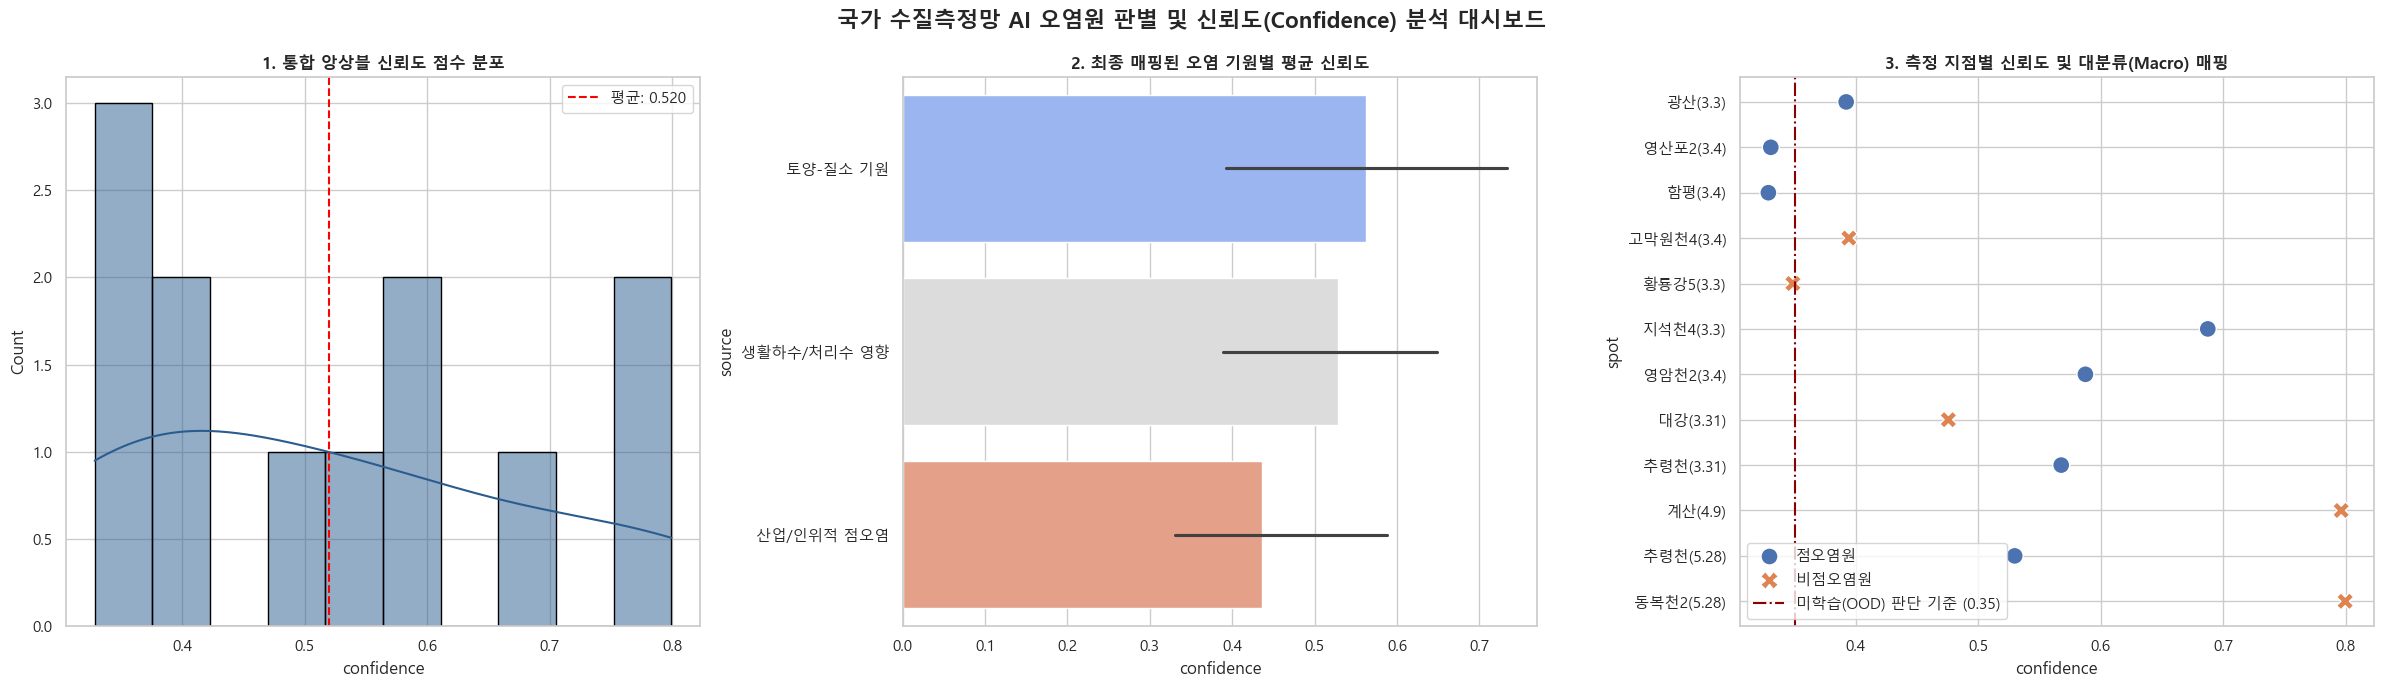

 -> [시각화 완료] 저장 경로: 'C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/데이터 입력\pollution_source_confidence_dashboard_v3.png'

[*] 전체 하이브리드 파이프라인 수행 완료!
[-] 평가 데이터 수: 12 건
[-] 미학습 오염원(OOD) 포착 건수: 0 건 (신뢰도 < 0.0)
[-] 학습 시 반영된 오염원 범주 수: 11 개 범주 완벽 포함
[-] 최종 예측 결과 저장 경로: C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/데이터 입력/test_predictions_ver3.csv
[-] 총 소요 시간: 23.0 초



In [14]:
# ==========================================
# 실행 모듈
# ==========================================
if __name__ == "__main__":
    train_csv_path = "C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/데이터 입력/train_ver3.csv"
    test_csv_path  = "C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/데이터 입력/test_ver3.csv"
    output_predictions_path = "C:/Users/User/Desktop/연구지점 데이터 정리/실측자료 기반 오염원 판별/데이터 입력/test_predictions_ver3.csv"
    
    if os.path.exists(train_csv_path) and os.path.exists(test_csv_path):
        run_integrated_pipeline(train_csv_path, test_csv_path, output_predictions_path, ood_threshold=0.0)
    else:
        print("[오류] 지정된 경로에 'train_ver3.csv' 또는 'test_ver3.csv' 파일이 존재하지 않습니다.")